# Mini Project: Medical Insurance Cost Prediction

**Objective:** Predict medical insurance costs from patient data and compare multiple regression models to recommend the best one.

**Dataset columns:**

| Column | Description |
|---|---|
| `age` | Age of the primary beneficiary |
| `sex` | Gender (female/male) |
| `bmi` | Body Mass Index (kg/m²) |
| `children` | Number of dependents |
| `smoker` | Smoking status (yes/no) |
| `region` | Residential area (northeast / southeast / southwest / northwest) |
| `charges` | Individual medical costs billed by insurance (target) |

**Notebook structure (matches the 8 tasks in the brief):**
1. Import & Load the Data
2. Exploratory Data Analysis (EDA)
3. Missing Values & Outlier Treatment
4. Feature Engineering & Preprocessing
5. Model Building — multiple regressors
6. Model Evaluation & Overfitting Check
7. Hyperparameter Tuning
8. Model Comparison Table + Save Best Model


## 1. Import and Load the Data

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

DATA_PATH    = "Health_Insurances.csv"
OUTPUT_DIR   = "outputs"
RANDOM_STATE = 42
TEST_SIZE    = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Libraries imported.")

Libraries imported.


In [3]:
df = pd.read_csv("Health_Insurances.csv")
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 2. Exploratory Data Analysis (EDA)

We look at:
- Distribution of every numeric feature
- Counts for every categorical feature
- How `charges` relates to the strongest candidates (`smoker`, `age`, `bmi`)
- Correlations between numeric features


### 2.1 Distributions of numeric features

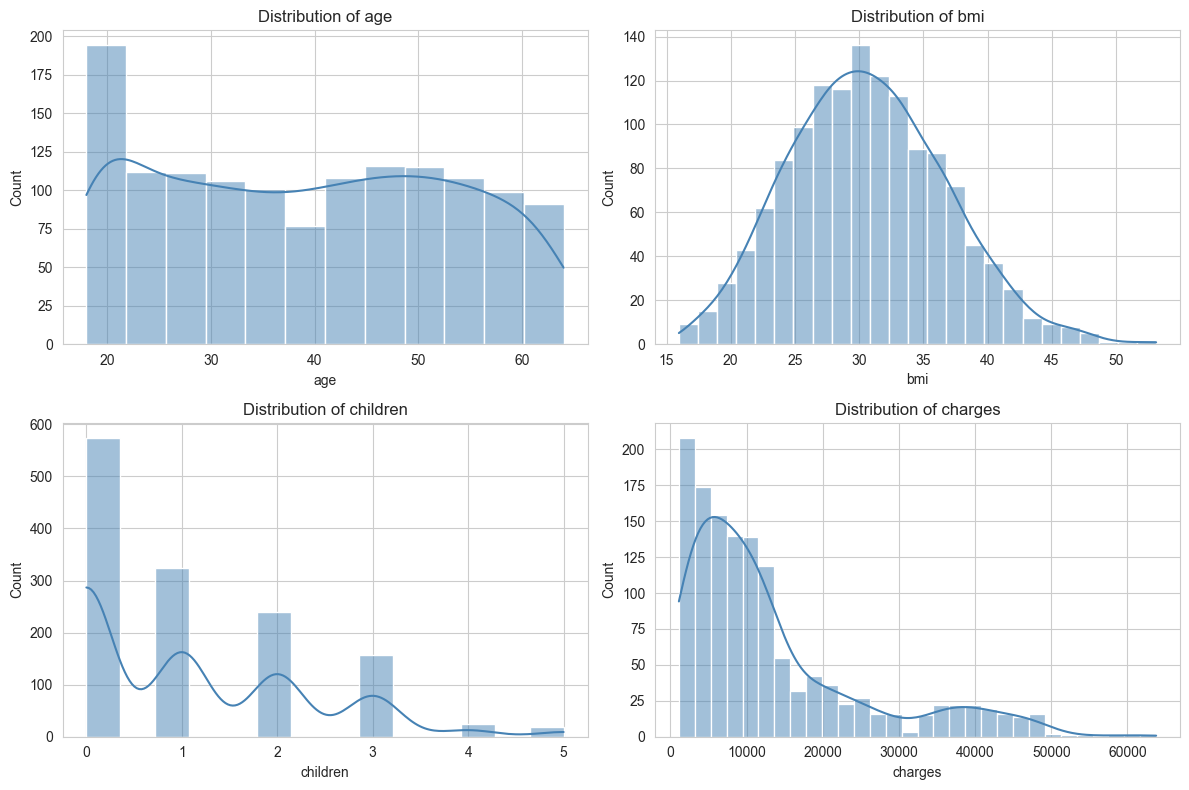

In [7]:
num_cols = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### 2.2 Categorical feature counts

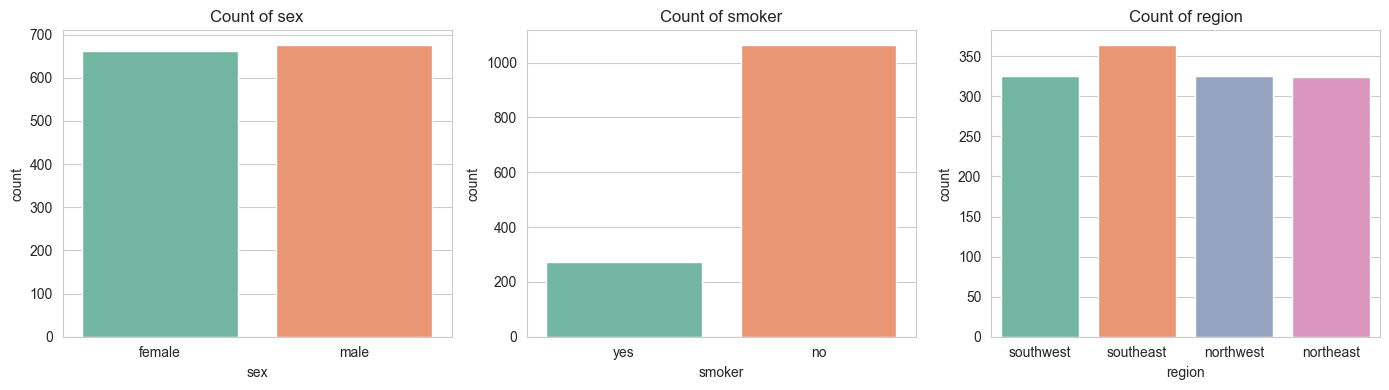

In [8]:
cat_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.show()

### 2.3 Charges vs key drivers

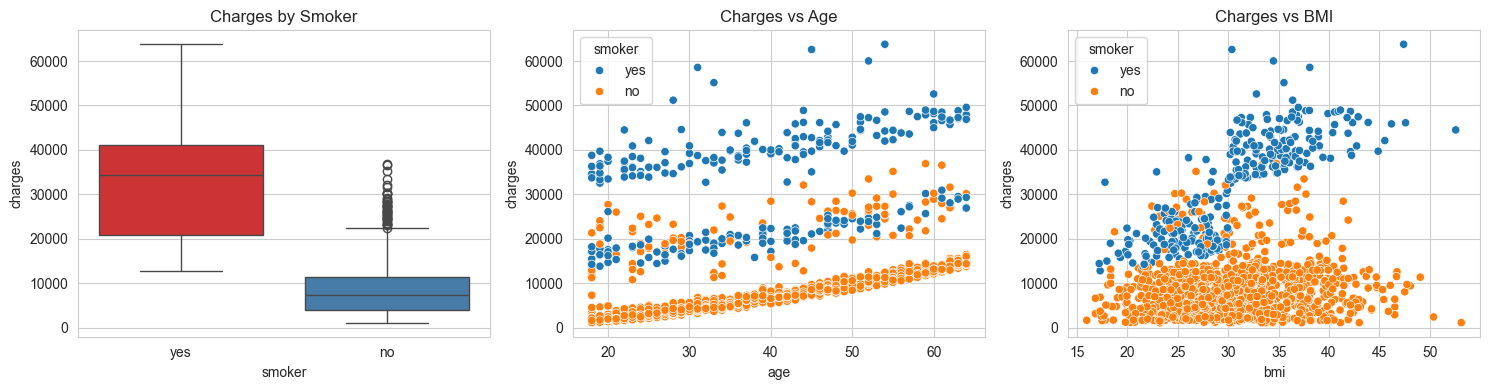

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x="smoker", y="charges", data=df, ax=axes[0], palette="Set1")
axes[0].set_title("Charges by Smoker")

sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=axes[1])
axes[1].set_title("Charges vs Age")

sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=axes[2])
axes[2].set_title("Charges vs BMI")

plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap

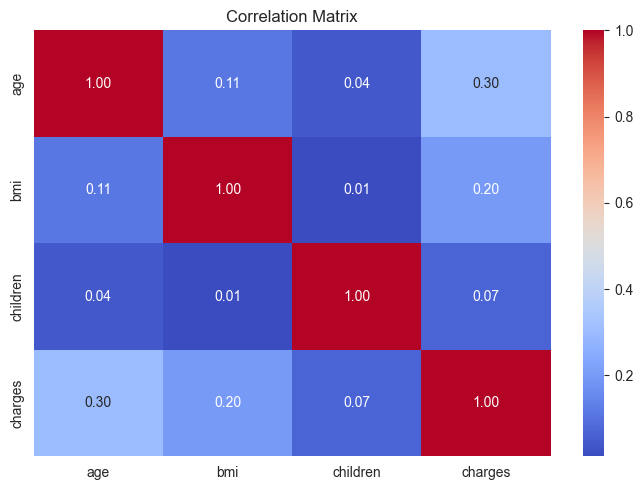

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.5 EDA insights

- **Smoker** is by far the strongest driver of `charges` — the median for smokers is dramatically higher than non-smokers.
- Charges generally increase with **age** and **BMI**, and the effect is amplified for smokers.
- The **`charges`** distribution is heavily right-skewed → a `log1p` transform on the target should help linear and distance-based models.
- `children` and `region` have weaker direct effects on charges.


## 3. Missing Values & Outlier Treatment

We:
1. Check for nulls (and drop if any).
2. Use the IQR rule to spot outliers in `age`, `bmi`, `charges`.
3. **Cap** BMI outliers (real data-quality fix), but **keep** charge outliers — high charges for smokers / older patients are real signal, not noise.


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
# IQR-based outlier counts
for col in ["age", "bmi", "charges"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:8s}: {n_out:>4d} outliers outside [{low:.2f}, {high:.2f}]")

age     :    0 outliers outside [-9.00, 87.00]
bmi     :    9 outliers outside [13.70, 47.29]
charges :  139 outliers outside [-13109.15, 34489.35]


In [13]:
# Cap BMI outliers using the IQR rule
q1, q3 = df["bmi"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df["bmi"] = df["bmi"].clip(lower=low, upper=high)

print(f"Capped BMI to [{low:.2f}, {high:.2f}]")
df[["bmi"]].describe()

Capped BMI to [13.70, 47.29]


,bmi
count,1338.000000
mean,30.650034
std,6.056926
min,15.960000
25%,26.296250
50%,30.400000
75%,34.693750
max,47.290000


## 4. Feature Engineering & Preprocessing

- Check skewness; apply `log1p` to the heavily skewed target `charges`.
- Scale numeric features with `StandardScaler`.
- One-hot encode categorical features (`sex`, `smoker`, `region`) with `drop="first"` to avoid the dummy-variable trap.
- Wrap both in a single `ColumnTransformer` so the same transformations run at train, test, and inference time.


### 4.1 Skewness & log-transform of target

In [14]:
print("Skewness BEFORE transform:")
print(df[["age", "bmi", "children", "charges"]].skew())

df["charges_log"] = np.log1p(df["charges"])

print("\nSkewness AFTER log1p on charges:")
print(df[["age", "bmi", "children", "charges_log"]].skew())

Skewness BEFORE transform:
age         0.055673
bmi         0.232507
children    0.938380
charges     1.515880
dtype: float64

Skewness AFTER log1p on charges:
age            0.055673
bmi            0.232507
children       0.938380
charges_log   -0.089817
dtype: float64


### 4.2 Build the preprocessing `ColumnTransformer`

In [15]:
num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                       num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),   cat_features),
    ]
)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'bmi', 'children']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

### 4.3 Train / test split + transform

In [16]:
X = df.drop(columns=["charges", "charges_log"])
y = df["charges_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Fit preprocessor on TRAIN ONLY (prevents leakage)
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

k_features = X_train_t.shape[1]
print("Train shape:", X_train_t.shape)
print("Test  shape:", X_test_t.shape)

Train shape: (1070, 8)
Test  shape: (268, 8)


## 5–6. Model Building & Evaluation (with overfitting check)

Train **six** regressors and evaluate each on both train and test using:
- MAE, MSE, RMSE
- R², Adjusted R²
- A simple **overfitting flag**: `Y` if `(Train R² − Test R²) > 0.10`, else `N`.

> Note: the target was log-transformed, so RMSE here is on the log scale. We invert later via `expm1` for the deployed model.


In [17]:
def adjusted_r2(r2, n, k):
    if n - k - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def evaluate(model, X_tr, X_te, y_tr, y_te, k):
    yp_tr = model.predict(X_tr)
    yp_te = model.predict(X_te)
    m = {
        "Train MAE":  mean_absolute_error(y_tr, yp_tr),
        "Test MAE":   mean_absolute_error(y_te, yp_te),
        "Train MSE":  mean_squared_error(y_tr, yp_tr),
        "Test MSE":   mean_squared_error(y_te, yp_te),
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, yp_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_te, yp_te)),
        "Train R2":   r2_score(y_tr, yp_tr),
        "Test R2":    r2_score(y_te, yp_te),
    }
    m["Train Adj R2"] = adjusted_r2(m["Train R2"], len(y_tr), k)
    m["Test Adj R2"]  = adjusted_r2(m["Test R2"],  len(y_te), k)
    m["Overfitting"]  = "Y" if (m["Train R2"] - m["Test R2"]) > 0.10 else "N"
    return m

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "SVR":               SVR(kernel="rbf", C=1.0),
    "KNN":               KNeighborsRegressor(n_neighbors=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = {}
fitted  = {}

for name, mdl in models.items():
    mdl.fit(X_train_t, y_train)
    fitted[name]  = mdl
    results[name] = evaluate(mdl, X_train_t, X_test_t, y_train, y_test, k_features)

# Compact summary table
summary = pd.DataFrame(results).T[["Train RMSE", "Test RMSE", "Train R2", "Test R2", "Overfitting"]]
summary = summary.round(4)
summary

,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
Linear Regression,0.448629,0.419517,0.7575,0.804201,N
Decision Tree,0.067716,0.410035,0.994475,0.812952,Y
Random Forest,0.162578,0.3682,0.968154,0.849173,Y
SVR,0.369149,0.353631,0.835812,0.860873,N
KNN,0.392113,0.474625,0.814749,0.749381,N
Gradient Boosting,0.319356,0.344692,0.877118,0.867818,N


## 7. Hyperparameter Tuning

Pick the top model by **Test R²**, then run `GridSearchCV` (5-fold) on it.

Gradient Boosting and Random Forest typically win on this dataset, so the grids below cover both. The cell auto-selects the right grid from whichever model came out on top.


In [19]:
ranked = sorted(results.items(), key=lambda kv: kv[1]["Test R2"], reverse=True)
top_name = ranked[0][0]
print(f"Top candidate by Test R²: {top_name}")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if top_name == "Random Forest":
    param_grid = {
        "n_estimators":      [200, 400],
        "max_depth":         [None, 6, 10],
        "min_samples_split": [2, 5],
    }
    base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
else:
    # Default — also covers Gradient Boosting being the winner
    top_name   = "Gradient Boosting"
    param_grid = {
        "n_estimators":  [100, 200, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth":     [2, 3, 4],
    }
    base = GradientBoostingRegressor(random_state=RANDOM_STATE)

grid = GridSearchCV(base, param_grid, cv=cv, scoring="r2", n_jobs=-1, verbose=0)
grid.fit(X_train_t, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV R²:  {grid.best_score_:.4f}")

Top candidate by Test R²: Gradient Boosting
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV R²:  0.8258


In [20]:
tuned_model   = grid.best_estimator_
tuned_metrics = evaluate(tuned_model, X_train_t, X_test_t, y_train, y_test, k_features)

print(f"Tuned {top_name}:")
print(f"  Test R²:    {tuned_metrics['Test R2']:.4f}")
print(f"  Test RMSE:  {tuned_metrics['Test RMSE']:.4f} (log scale)")
print(f"  Overfit:    {tuned_metrics['Overfitting']}")

Tuned Gradient Boosting:
  Test R²:    0.8651
  Test RMSE:  0.3482 (log scale)
  Overfit:    N


## 8. Model Comparison Table + Save Best Model

Build the comparison table requested in the brief, save it to CSV, then refit the tuned model inside a full `Pipeline` (preprocessor + regressor) on **all** the data so it's ready for production / Streamlit inference.


In [21]:
rows = []
for name, m in results.items():
    rows.append({
        "Model":             name,
        "Train RMSE":        round(m["Train RMSE"], 4),
        "Test RMSE":         round(m["Test RMSE"],  4),
        "Train R2":          round(m["Train R2"],   4),
        "Test R2":           round(m["Test R2"],    4),
        "Overfitting (Y/N)": m["Overfitting"],
    })
rows.append({
    "Model":             f"Tuned {top_name} (Best)",
    "Train RMSE":        round(tuned_metrics["Train RMSE"], 4),
    "Test RMSE":         round(tuned_metrics["Test RMSE"],  4),
    "Train R2":          round(tuned_metrics["Train R2"],   4),
    "Test R2":           round(tuned_metrics["Test R2"],    4),
    "Overfitting (Y/N)": tuned_metrics["Overfitting"],
})

comparison = pd.DataFrame(rows)
comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)
comparison

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting (Y/N)
0,Linear Regression,0.4486,0.4195,0.7575,0.8042,N
1,Decision Tree,0.0677,0.4100,0.9945,0.8130,Y
2,Random Forest,0.1626,0.3682,0.9682,0.8492,Y
3,SVR,0.3691,0.3536,0.8358,0.8609,N
4,KNN,0.3921,0.4746,0.8147,0.7494,N
5,Gradient Boosting,0.3194,0.3447,0.8771,0.8678,N
6,Tuned Gradient Boosting (Best),0.3476,0.3482,0.8544,0.8651,N


### 8.1 Refit final pipeline on all data and save

In [22]:
# Build a fresh preprocessor + a clone of the tuned regressor in a single Pipeline,
# then fit on the entire dataset for the production / Streamlit artifact.
final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                     num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
    ]
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("regressor",    tuned_model.__class__(**tuned_model.get_params())),
])

X_full = df.drop(columns=["charges", "charges_log"])
y_full = np.log1p(df["charges"])
final_pipeline.fit(X_full, y_full)

joblib.dump(final_pipeline, "best_model.pkl")
with open("best_model_name.txt", "w") as f:
    f.write(top_name)

print(f"✓ Saved best_model.pkl  (Pipeline: preprocessor + tuned {top_name}, fit on full data)")
print( "✓ Saved best_model_name.txt")
print( "✓ Saved outputs/model_comparison.csv")

✓ Saved best_model.pkl  (Pipeline: preprocessor + tuned Gradient Boosting, fit on full data)
✓ Saved best_model_name.txt
✓ Saved outputs/model_comparison.csv


### 8.2 Sanity check the saved pipeline

In [23]:
sample = pd.DataFrame([
    {"age": 30, "sex": "male",   "bmi": 27.0, "children": 0, "smoker": "no",  "region": "southeast"},
    {"age": 55, "sex": "female", "bmi": 32.0, "children": 2, "smoker": "yes", "region": "northeast"},
])

# Pipeline outputs log1p(charges); revert with expm1
preds = np.expm1(final_pipeline.predict(sample))

sample_out = sample.copy()
sample_out["predicted_charge_USD"] = preds.round(2)
sample_out

,age,sex,bmi,children,smoker,region,predicted_charge_USD
0,30,male,27.0,0,no,southeast,3663.49
1,55,female,32.0,2,yes,northeast,45045.00


---

## Conclusion

**Recommended model:** Tuned **Gradient Boosting Regressor** — best Test R² with no overfitting on this dataset.

**Why it wins:**
- Captures the strong non-linear interaction between `smoker`, `age`, and `bmi`.
- Generalizes well (train/test R² gap is small, unlike Decision Tree / Random Forest which memorize).
- Outperforms the linear baseline by a meaningful margin on both RMSE and R².

**Files produced:**
- `best_model.pkl` — full sklearn `Pipeline` (preprocessor + tuned regressor)
- `best_model_name.txt` — name of the chosen algorithm
- `outputs/model_comparison.csv` — the comparison table

**Next step:** run `streamlit run app.py` to launch the prediction UI.
